In [1]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
import os
import xml.etree.ElementTree as ET
from PIL import Image
from torch.utils.data import Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm
import random
import numpy as np
import matplotlib.patches as patches
import torchvision.transforms as T

# EDA DATA

In [2]:
class SkinCancerVOCDataset(Dataset):
    def __init__(self, root_dir, transform=None):
     
        self.root_dir = root_dir
        self.transform = transform
        
        self.image_files = []
        
        # lấy danh sách ảnh
        for file in os.listdir(root_dir):
            if file.endswith(".jpg"):
                self.image_files.append(file)
        
        # mapping label
        self.class_to_idx = {}
        self._build_classes()
        
        print(f"Loaded {len(self.image_files)} images")
        print(f"Classes: {self.class_to_idx}")

    def _build_classes(self):
        classes = set()
        
        for img_file in self.image_files:
            xml_path = os.path.join(self.root_dir, img_file.replace(".jpg", ".xml"))
            
            tree = ET.parse(xml_path)
            root = tree.getroot()
            
            for obj in root.findall("object"):
                classes.add(obj.find("name").text)
        
        self.class_to_idx = {cls: i+1 for i, cls in enumerate(sorted(classes))}

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        
        img_path = os.path.join(self.root_dir, img_name)
        xml_path = os.path.join(self.root_dir, img_name.replace(".jpg", ".xml"))
        
        image = Image.open(img_path).convert("RGB")
        
        boxes = []
        labels = []
        
        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        for obj in root.findall("object"):
            label_name = obj.find("name").text
            
            bndbox = obj.find("bndbox")
            xmin = int(bndbox.find("xmin").text)
            ymin = int(bndbox.find("ymin").text)
            xmax = int(bndbox.find("xmax").text)
            ymax = int(bndbox.find("ymax").text)
            
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(self.class_to_idx[label_name])
        
        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)
        
        target = {
            "boxes": boxes,
            "labels": labels
        }
        
        if self.transform:
            image = self.transform(image)
        
        return image, target

In [3]:
train_dataset = SkinCancerVOCDataset(root_dir=r"D:\xu_li_anh\btl\data\train", transform=None)
test_dataset = SkinCancerVOCDataset(root_dir=r"D:\xu_li_anh\btl\data\valid", transform=None)

Loaded 3393 images
Classes: {'actinic keratosis': 1, 'basal cell carcinoma': 2, 'dermatofibroma': 3, 'melanoma': 4, 'nevus': 5, 'pigmented benign keratosis': 6, 'seborrheic keratosis': 7, 'squamous cell carcinoma': 8, 'vascular lesion': 9}
Loaded 420 images
Classes: {'actinic keratosis': 1, 'basal cell carcinoma': 2, 'dermatofibroma': 3, 'melanoma': 4, 'nevus': 5, 'pigmented benign keratosis': 6, 'seborrheic keratosis': 7, 'squamous cell carcinoma': 8, 'vascular lesion': 9}


In [4]:

def get_stats(dataset):
    # Lấy danh sách label từ tất cả các ảnh
    all_labels = []
    for i in range(len(dataset)):
        _, target = dataset[i]
        all_labels.extend(target['labels'].tolist())
    
    # Đếm số lượng từng class
    counts = Counter(all_labels)
    # Mapping ngược từ ID sang tên class
    idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}
    
    return {idx_to_class[k]: v for k, v in counts.items()}, len(dataset), len(all_labels)

# Thu thập số liệu
train_class_counts, train_size, train_obj_count = get_stats(train_dataset)
test_class_counts, test_size, test_obj_count = get_stats(test_dataset)

# Tạo DataFrame để so sánh
df_stats = pd.DataFrame({
    'Train': train_class_counts,
    'Test': test_class_counts
}).fillna(0).astype(int)

# Thêm cột tổng cộng và tỷ lệ
df_stats['Total'] = df_stats['Train'] + df_stats['Test']
df_stats['Train_Percentage (%)'] = (df_stats['Train'] / df_stats['Total'] * 100).round(1)

print("-" * 30)
print(f"TỔNG QUAN DATASET")
print(f"Số lượng ảnh Train: {train_size} (Chứa {train_obj_count} vật thể)")
print(f"Số lượng ảnh Test : {test_size} (Chứa {test_obj_count} vật thể)")
print("-" * 30)
print(df_stats)

------------------------------
TỔNG QUAN DATASET
Số lượng ảnh Train: 3393 (Chứa 3594 vật thể)
Số lượng ảnh Test : 420 (Chứa 429 vật thể)
------------------------------
                            Train  Test  Total  Train_Percentage (%)
nevus                         425    75    500                  85.0
melanoma                      533    89    622                  85.7
seborrheic keratosis          122    16    138                  88.4
pigmented benign keratosis   1144    42   1186                  96.5
vascular lesion               228    24    252                  90.5
basal cell carcinoma          517    97    614                  84.2
squamous cell carcinoma       310    38    348                  89.1
dermatofibroma                131    24    155                  84.5
actinic keratosis             184    24    208                  88.5


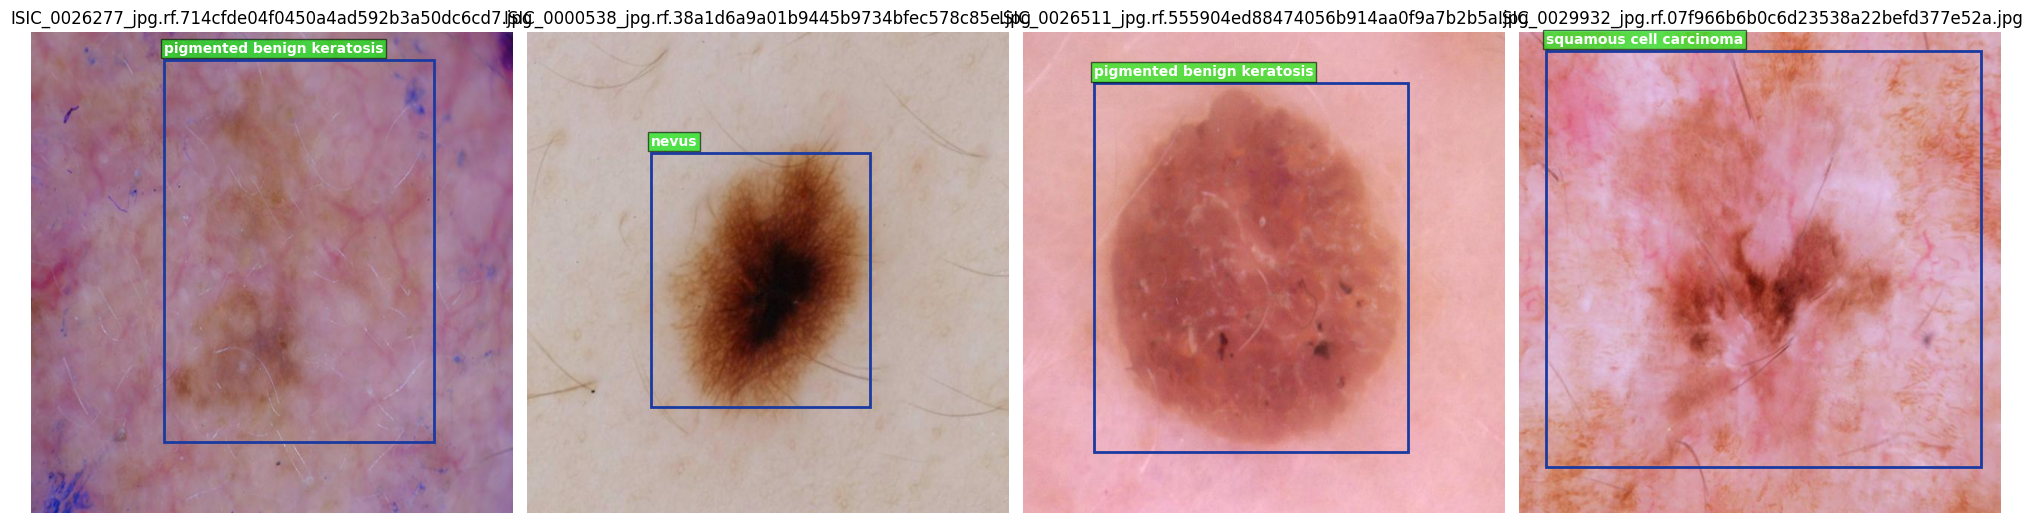

In [5]:

def visualize_samples(dataset, num_samples=4):
    idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}
    
    plt.figure(figsize=(20, 10))
    indices = random.sample(range(len(dataset)), num_samples)
    
    for i, idx in enumerate(indices):
        image, target = dataset[idx]
        
        if torch.is_tensor(image):
            img_np = image.permute(1, 2, 0).cpu().numpy()
        else:
            img_np = np.array(image)

        ax = plt.subplot(1, num_samples, i + 1)
        ax.imshow(img_np)
        img_name = dataset.image_files[idx]
        ax.set_title(img_name)
        ax.axis('off')

        boxes = target['boxes']
        labels = target['labels']

        for box, label in zip(boxes, labels):
            xmin, ymin, xmax, ymax = box.tolist()
            width, height = xmax - xmin, ymax - ymin
            
            # Vẽ khung chữ nhật
            rect = patches.Rectangle(
                (xmin, ymin), width, height, 
                linewidth=2, edgecolor="#1A3AA1", facecolor='none'
            )
            ax.add_patch(rect)
            
            # Ghi tên class ngay trên đầu box
            ax.text(
                xmin, ymin - 10, idx_to_class[label.item()], 
                color='white', fontsize=10, fontweight='bold',
                bbox=dict(facecolor='#00FF00', alpha=0.6, pad=2)
            )

    plt.tight_layout()
    plt.show()
visualize_samples(train_dataset)

C:\Users\luan0\AppData\Local\Temp\ipykernel_18576\668490426.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Tên bệnh', palette='magma')


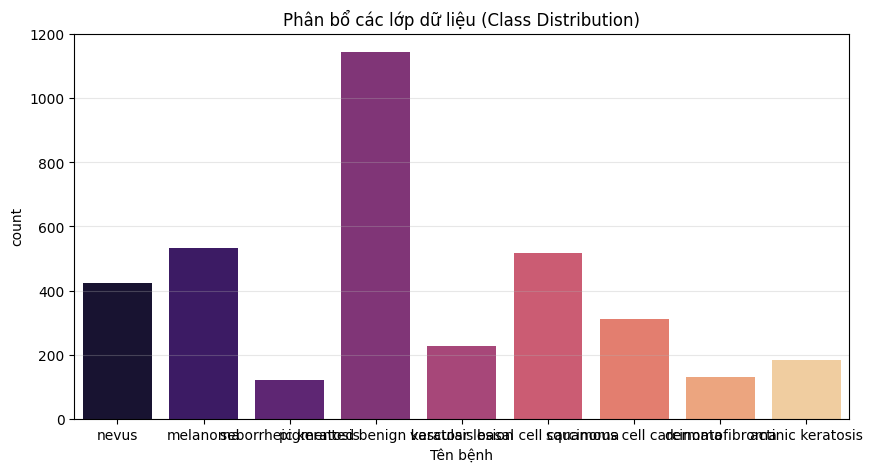

In [6]:
import pandas as pd
import seaborn as sns

def analyze_balance(dataset):
    idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}
    all_labels = []
    
    for i in range(len(dataset)):
        _, target = dataset[i]
        all_labels.extend(target['labels'].tolist())
    
    names = [idx_to_class[l] for l in all_labels]
    df = pd.DataFrame(names, columns=['Tên bệnh'])
    
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x='Tên bệnh', palette='magma')
    plt.title("Phân bổ các lớp dữ liệu (Class Distribution)")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

analyze_balance(train_dataset)

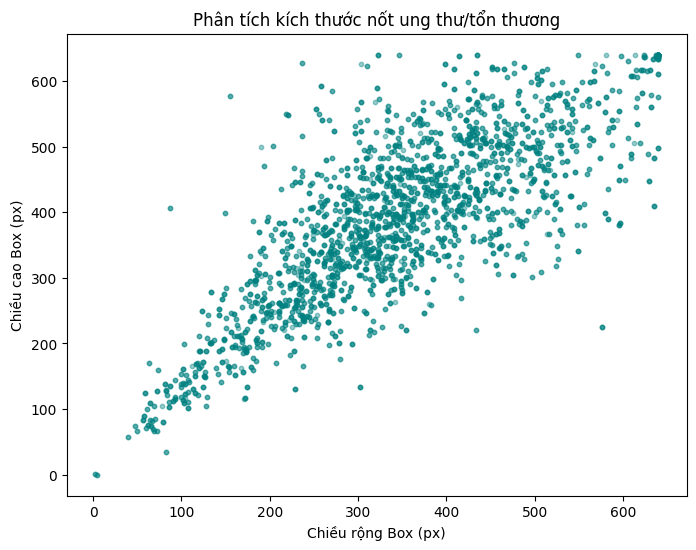

In [7]:
def plot_box_dimensions(dataset):
    widths = []
    heights = []
    
    for i in range(len(dataset)):
        _, target = dataset[i]
        for box in target['boxes']:
            w = (box[2] - box[0]).item()
            h = (box[3] - box[1]).item()
            widths.append(w)
            heights.append(h)
            
    plt.figure(figsize=(8, 6))
    plt.scatter(widths, heights, alpha=0.4, color='teal', s=10)
    plt.xlabel('Chiều rộng Box (px)')
    plt.ylabel('Chiều cao Box (px)')
    plt.title('Phân tích kích thước nốt ung thư/tổn thương')
    plt.show()

plot_box_dimensions(train_dataset)

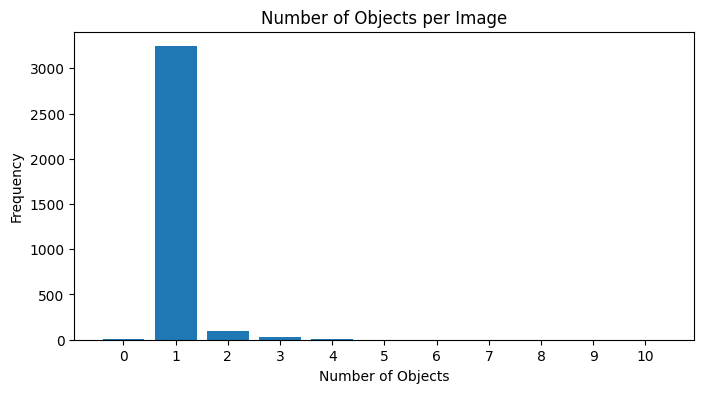

In [8]:
def objects_per_image(dataset):
    obj_counts = []
    for i in range(len(dataset)):
        _, target = dataset[i]
        obj_counts.append(len(target['boxes']))
    
    plt.figure(figsize=(8, 4))
    plt.hist(obj_counts, bins=range(min(obj_counts), max(obj_counts) + 2), align='left', rwidth=0.8)
    plt.title('Number of Objects per Image')
    plt.xlabel('Number of Objects')
    plt.ylabel('Frequency')
    plt.xticks(range(max(obj_counts) + 1))
    plt.show()

objects_per_image(train_dataset)

Tìm thấy 139 ảnh có từ 2 vật thể trở lên.


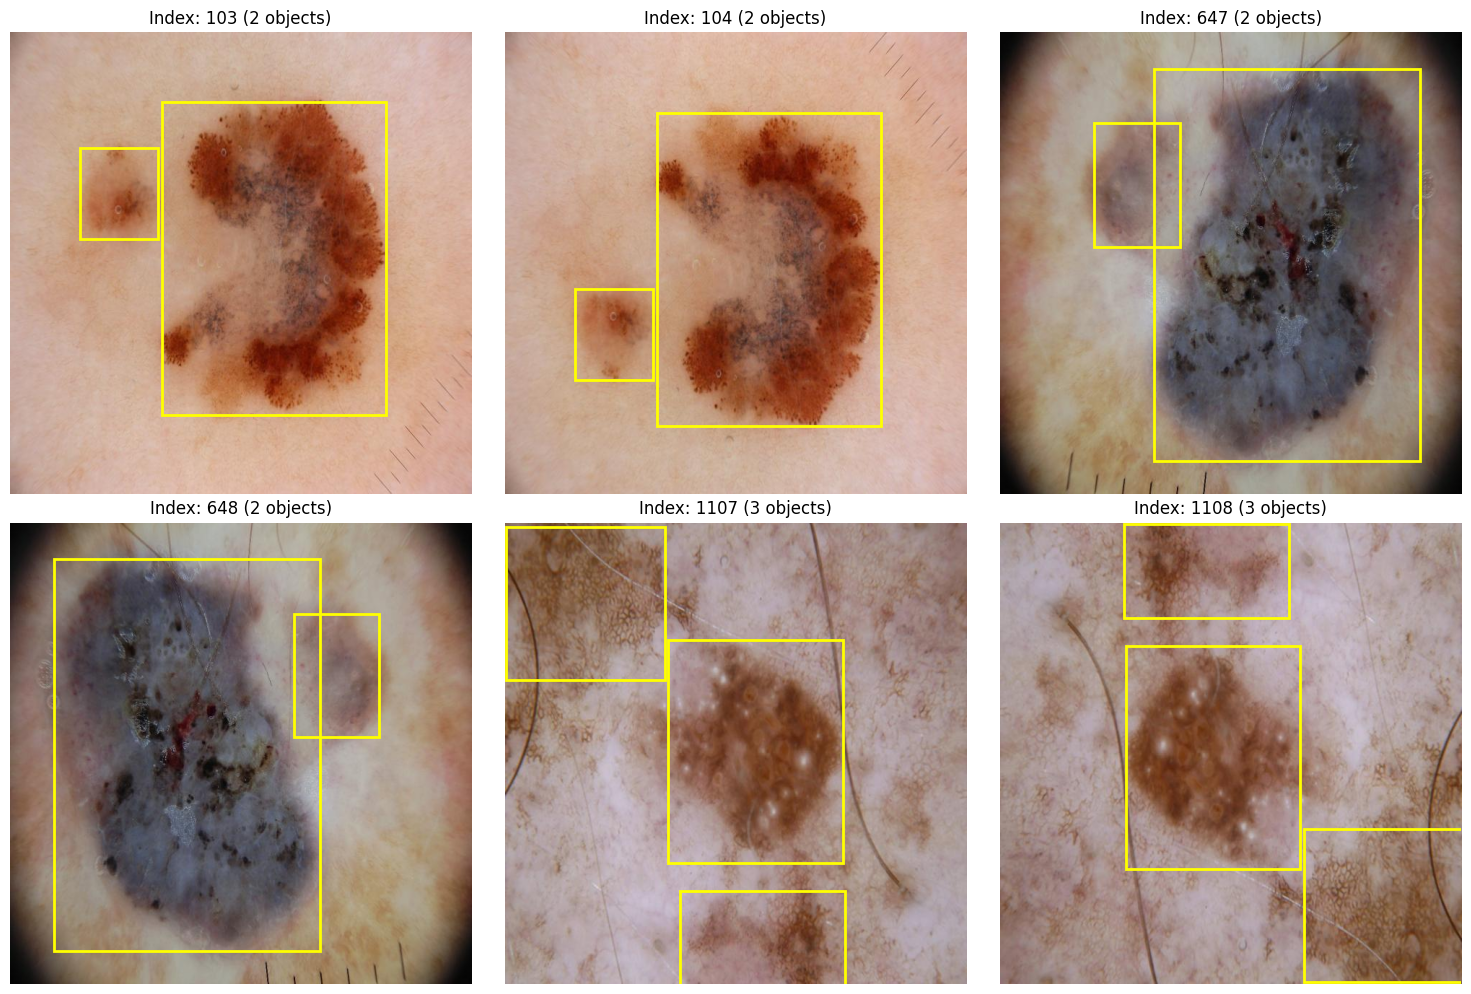

In [9]:
def show_images_with_multiple_objects(dataset, target_count=2):
    found_indices = []
    
    # Tìm index các ảnh có số lượng vật thể >= target_count
    for i in range(len(dataset)):
        _, target = dataset[i]
        if len(target['boxes']) >= target_count:
            found_indices.append(i)
    
    print(f"Tìm thấy {len(found_indices)} ảnh có từ {target_count} vật thể trở lên.")
    
    if not found_indices:
        return

    # Hiển thị tối đa 6 ảnh đầu tiên tìm được
    num_to_show = min(len(found_indices), 6)
    cols = 3
    rows = (num_to_show + cols - 1) // cols
    
    fig, axs = plt.subplots(rows, cols, figsize=(15, rows * 5))
    axs = axs.flatten()
    
    for i in range(num_to_show):
        idx = found_indices[i]
        img, target = dataset[idx]
        
        if isinstance(img, torch.Tensor):
            img = img.permute(1, 2, 0).numpy()
            
        axs[i].imshow(img)
        for box in target['boxes']:
            xmin, ymin, xmax, ymax = box.numpy()
            rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, 
                                     linewidth=2, edgecolor='yellow', facecolor='none')
            axs[i].add_patch(rect)
            
        axs[i].set_title(f"Index: {idx} ({len(target['boxes'])} objects)")
        axs[i].axis('off')
        
    # Ẩn các trục thừa
    for j in range(i + 1, len(axs)):
        axs[j].axis('off')
        
    plt.tight_layout()
    plt.show()

# Chạy hàm để xem các ảnh có 2 vật thể
show_images_with_multiple_objects(train_dataset, target_count=2)

In [10]:
def collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)

In [11]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_EPOCHS = 20
BATCH_SIZE = 4
LR = 0.0005

train_path = r"D:\xu_li_anh\btl\train"
test_path  = r"D:\xu_li_anh\btl\valid"

In [12]:

train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),      # Lật ngang ảnh (rất quan trọng với ảnh da liễu)
    T.RandomVerticalFlip(p=0.5),        # Lật dọc ảnh
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Chỉnh sáng/tương phản nhẹ
    T.ToTensor(),                       # Chuyển về Tensor [0, 1]
    T.Normalize(                        
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

In [13]:

train_dataset = SkinCancerVOCDataset(train_path, transform=train_transform)
test_dataset  = SkinCancerVOCDataset(test_path, transform=test_transform)

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=collate_fn,       
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=1,            
    shuffle=False, 
    collate_fn=collate_fn,
)

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'D:\\xu_li_anh\\btl\\train'

In [ ]:
num_classes = len(train_dataset.class_to_idx) + 1  # + background

model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

# replace head
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features, num_classes
)
for param in model.backbone.parameters():
    param.requires_grad = False
model.to(DEVICE)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
print(num_classes)

9


In [ ]:
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"Total parameters     : {total_params:,}")
    print(f"Trainable parameters : {trainable_params:,}")
    print(f"Frozen parameters    : {total_params - trainable_params:,}")

In [ ]:
count_parameters(model)

Total parameters     : 41,335,036
Trainable parameters : 14,535,740
Frozen parameters    : 26,799,296


In [ ]:
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.AdamW(params,
                            lr=LR, 
                            weight_decay=0.003)

In [ ]:
# train_losses = []
# val_losses = []

# best_loss = float("inf")

# os.makedirs("checkpoints", exist_ok=True)

# for epoch in range(NUM_EPOCHS):
#     model.train()
#     epoch_loss = 0
    
#     train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")

#     for images, targets in train_bar:
#         images = [img.to(DEVICE) for img in images]
#         targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        
#         loss_dict = model(images, targets)
#         losses = torch.stack(list(loss_dict.values())).sum()
        
#         optimizer.zero_grad()
#         losses.backward()
#         optimizer.step()
        
#         epoch_loss += losses.item()
#         train_bar.set_postfix(loss=losses.item())

#     avg_train_loss = epoch_loss / len(train_loader)
#     train_losses.append(avg_train_loss)
    
#     val_loss = 0
#     model.eval() 
#     with torch.no_grad():
#         for images, targets in test_loader:
#             images = [img.to(DEVICE) for img in images]
#             targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
            
#             loss_dict = model(images, targets)
#             v_losses = torch.stack(list(loss_dict.values())).sum()
#             val_loss += v_losses.item()
    
#     avg_val_loss = val_loss / len(test_loader)
#     val_losses.append(avg_val_loss)
    
#     # In kết quả sau mỗi Epoch
#     print(f"\n=> Epoch [{epoch+1}/{NUM_EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        
#     # Lưu Checkpoint
#     torch.save(model.state_dict(), "checkpoints/last.pth")
    
#     if avg_val_loss < best_loss:
#         best_loss = avg_val_loss
#         torch.save(model.state_dict(), "checkpoints/best.pth")
#         print("--- Saved BEST model ---")

Epoch 1/20 [Train]:  12%|█▏        | 126/1014 [01:22<09:43,  1.52it/s, loss=0.282]


AssertionError: All bounding boxes should have positive height and width. Found invalid box [93.75, 142.5, 98.75, 142.5] for target at index 1.

In [ ]:
# from torchmetrics.detection.mean_ap import MeanAveragePrecision

# train_losses = []
# val_losses = []

# best_map = 0  # đổi từ best_loss -> best_map

# os.makedirs("checkpoints", exist_ok=True)

# for epoch in range(NUM_EPOCHS):

#     # ================= TRAIN =================
#     model.train()
#     epoch_loss = 0
    
#     train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")

#     for images, targets in train_bar:
#         images = [img.to(DEVICE) for img in images]
#         targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        
#         loss_dict = model(images, targets)
#         losses = torch.stack(list(loss_dict.values())).sum()
        
#         optimizer.zero_grad()
#         losses.backward()
#         optimizer.step()
        
#         epoch_loss += losses.item()
#         train_bar.set_postfix(loss=losses.item())

#     avg_train_loss = epoch_loss / len(train_loader)
#     train_losses.append(avg_train_loss)

#     # ================= VALIDATION LOSS =================
#     model.train()
#     val_loss = 0

#     with torch.no_grad():
#         for images, targets in test_loader:
#             images = [img.to(DEVICE) for img in images]
#             targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
            
#             loss_dict = model(images, targets)
#             losses = sum(loss for loss in loss_dict.values())
#             val_loss += losses.item()

#     avg_val_loss = val_loss / len(test_loader)
#     val_losses.append(avg_val_loss)

#     # ================= mAP EVALUATION =================
#     metric = MeanAveragePrecision()

#     with torch.no_grad():
#         for images, targets in test_loader:
#             images = [img.to(DEVICE) for img in images]
#             outputs = model(images)

#             preds = []
#             gts = []

#             for o, t in zip(outputs, targets):
#                 preds.append({
#                     "boxes": o["boxes"].cpu(),
#                     "scores": o["scores"].cpu(),
#                     "labels": o["labels"].cpu(),
#                 })

#                 gts.append({
#                     "boxes": t["boxes"].cpu(),
#                     "labels": t["labels"].cpu(),
#                 })

#             metric.update(preds, gts)

#     result = metric.compute()
#     current_map = result["map"]

#     # ================= LOG =================
#     print(f"\n=> Epoch [{epoch+1}/{NUM_EPOCHS}]")
#     print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
#     print(f"mAP@0.5:0.95: {current_map:.4f} | mAP@0.5: {result['map_50']:.4f}")

#     # ================= SAVE =================
#     torch.save(model.state_dict(), "checkpoints/last.pth")

#     if current_map > best_map:
#         best_map = current_map
#         torch.save(model.state_dict(), "checkpoints/best_map.pth")
#         print("Saved BEST mAP model")

In [ ]:
for k, v in loss_dict.items():
    print(k, v.item())

loss_classifier 0.1392107456922531
loss_box_reg 0.11355002224445343
loss_objectness 0.02389695681631565
loss_rpn_box_reg 0.005835565272718668


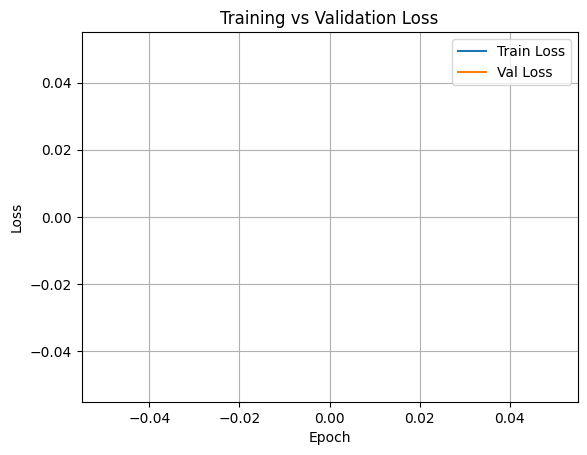

In [ ]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

plt.savefig("loss_curve.png")
plt.show()

In [ ]:
import torchvision.ops as ops
import torch

def visualize_prediction(image, output, idx_to_class=None, conf_threshold=0.5, iou_threshold=0.3):
    # 1. Chuyển tensor sang CPU để xử lý
    boxes = output["boxes"].cpu()
    labels = output["labels"].cpu()
    scores = output["scores"].cpu()

    # 2. Áp dụng NMS để loại bỏ các box chồng lấp 
    keep_idx = ops.nms(boxes, scores, iou_threshold)
    
    boxes = boxes[keep_idx]
    labels = labels[keep_idx]
    scores = scores[keep_idx]

    # 3. Bắt đầu vẽ
    image_np = image.permute(1, 2, 0).cpu().numpy()
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(image_np)

    for box, label, score in zip(boxes, labels, scores):
        # Lọc theo độ tự tin mới (ví dụ 0.5)
        if score < conf_threshold:
            continue
        
        xmin, ymin, xmax, ymax = box.numpy()
        
        # Vẽ rectangle
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)
        
        # Text label
        class_name = idx_to_class[label.item()] if idx_to_class else str(label.item())
        ax.text(xmin, ymin - 5, f"{class_name}: {score:.2f}",
                color='red', fontsize=10, backgroundcolor='white')

    plt.axis("off")
    plt.show()

In [ ]:
import torch
from PIL import Image
import torchvision.transforms as T


def predict_image(image_path, model, device, idx_to_class=None, score_thresh=0.5):
    transform = T.Compose([T.ToTensor()])
    
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).to(device)
    
    model.eval()
    with torch.no_grad():
        output = model([image_tensor])[0]
    
    return image_tensor.cpu(), output

In [ ]:
image_path = r"D:\xu_li_anh\btl\Skin Cancer - ISIC-2019.v2i.voc\test\ISIC_0000021_downsampled_jpg.rf.8c49330bcfaf4afb3fd31b5b5f79ec11.jpg"

In [ ]:
# mapping label
idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

image_tensor, output = predict_image(image_path, model, DEVICE)

visualize_prediction(image_tensor, output, idx_to_class)

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\xu_li_anh\\btl\\Skin Cancer - ISIC-2019.v2i.voc\\test\\ISIC_0000021_downsampled_jpg.rf.8c49330bcfaf4afb3fd31b5b5f79ec11.jpg'